# Discrete symmetries: representations, characters, and the construction of invariants

`SUN_Groups_Tutorial` does this for **continuous** groups — generators, the Lie
algebra, irreps of any dimension. This is the **discrete** counterpart: the finite
flavour symmetries ($\mathbb{Z}_N$, $S_3$, $A_4$) that model builders impose to forbid
terms and force relations between the ones that survive.

The pedagogy is the one the 3HDM-S₃ research notebooks use: **compute step by step, then
develop judgment**. Nothing below is typed in from the answer. The character table is
*derived* from generator matrices; the number of invariants is *predicted* by
orthogonality and then *checked* against explicit construction and against the library's
own enumerator.

Each section runs four moves — **set up** (look at the raw object), **collect** (let the
structure emerge), **recognise** (name what appeared and why it had to), **check** (from
group theory, not by re-running the same algebra) — and a blockquote asks you to commit
to an expectation *before* the cell that settles it.

**The one question this notebook is really about.** You impose a flavour symmetry on a
model. How many free parameters does the potential have? Which terms are forbidden? You
can answer both **before writing a single term**, and that is what the character table is
for.


In [ ]:
import itertools

import sympy as sp
sp.init_printing()

from feynlag import (S3, ZN, Scalar, SU2, U1, ExternalParameter, dag,
                     check_discrete_invariance)
from feynlag.groups.discrete import DiscreteSymmetry
from feynlag.suggest import reynolds_project, suggest_potential


def ok(msg):
    print("✓", msg)


---
## 1. The generators *are* the group

A finite group is handed to you as a couple of matrices and a promise: multiply them in
every possible order and you get the whole group, nothing more and nothing less. For
$S_3$ (the permutations of three objects) the library ships two generators in the
**real orthogonal basis** — a $2\pi/3$ rotation $a$ and a reflection $b$:

$$\rho_2(a)=\begin{pmatrix}-\tfrac12&-\tfrac{\sqrt3}{2}\\[2pt]\tfrac{\sqrt3}{2}&-\tfrac12\end{pmatrix},
\qquad
\rho_2(b)=\begin{pmatrix}1&0\\0&-1\end{pmatrix}.$$

Write them down rather than importing them — you should see the matrices you are
reasoning about — and then check the library agrees.

> **Before running the next cells.** $S_3$ has 6 elements. You have 2 matrices. Ask what
> relations they must satisfy for the closure to stop at 6 rather than running forever:
> a rotation by $2\pi/3$ has some order, a reflection has some order, and their product
> has a third. Guess all three. Then ask the harder question — if you only *multiply*
> generators, do you ever need inverses?


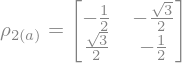

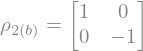

In [ ]:
# ---- MOVE 1: set up.  The three irreps of S3, as matrices. ----------------
c, s = sp.Rational(-1, 2), sp.sqrt(3) / 2
a2 = sp.Matrix([[c, -s], [s, c]])        # rho_2(a): rotation by 2 pi / 3
b2 = sp.Matrix([[1, 0], [0, -1]])        # rho_2(b): reflection

S3_GENS = {
    "1":  [sp.Matrix([[1]]), sp.Matrix([[1]])],    # trivial: everything -> +1
    "1p": [sp.Matrix([[1]]), sp.Matrix([[-1]])],   # sign rep: odd permutations -> -1
    "2":  [a2, b2],                                # the doublet
}
display(sp.Eq(sp.Symbol("rho_2(a)"), a2, evaluate=False))
display(sp.Eq(sp.Symbol("rho_2(b)"), b2, evaluate=False))


In [ ]:
# ---- MOVE 2: the defining relations. --------------------------------------
I2 = sp.eye(2)
rel = {"a^3 = e": sp.simplify(a2**3), "b^2 = e": sp.simplify(b2**2),
       "(ab)^2 = e": sp.simplify((a2 * b2)**2)}
for name, M in rel.items():
    print("  %-12s ->" % name, "identity" if M == I2 else "NOT the identity")
    assert M == I2
ok("a^3 = b^2 = (ab)^2 = e -- the presentation of S_3")

# because a^3 = e, a^{-1} = a^2 is itself a product of generators; likewise
# b^{-1} = b.  In a FINITE group every inverse is a positive power, so closing
# under multiplication alone is enough -- no inverses needed.
ok("every inverse is a positive power, so multiplication alone closes the group")


  a^3 = e      -> identity
  b^2 = e      -> identity
  (ab)^2 = e   -> identity
✓ a^3 = b^2 = (ab)^2 = e -- the presentation of S_3
✓ every inverse is a positive power, so multiplication alone closes the group


Now close them. Multiply until nothing new appears — that *is* the group.


In [ ]:
# ---- MOVE 3: close the generators into the whole group. -------------------
def close_group(gens):
    # All words in `gens`.  A word is a tuple of generator indices, so every
    # irrep can later be evaluated on the SAME element.  (feynlag does this
    # internally too, in suggest._group_elements.)
    n = gens[0].shape[0]
    key = lambda M: tuple(sp.nsimplify(sp.expand(x)) for x in M)
    seen = {key(sp.eye(n)): ()}
    frontier = [()]
    while frontier:
        nxt = []
        for word in frontier:
            for i in range(len(gens)):
                cand = word + (i,)
                M = sp.eye(n)
                for j in cand:
                    M = sp.expand(M * gens[j])
                if key(M) not in seen:
                    seen[key(M)] = cand
                    nxt.append(cand)
        frontier = nxt
    return list(seen.values())


WORDS = close_group(S3_GENS["2"])
print("words found:", WORDS)
print("|S_3| =", len(WORDS))
assert len(WORDS) == 6
ok("closing two matrices gives exactly 6 elements -- the generators ARE the group")


words found: [(), (0,), (1,), (0, 0), (0, 1), (1, 0)]
|S_3| = 6
✓ closing two matrices gives exactly 6 elements -- the generators ARE the group


Six elements from two matrices, and the closure terminated on its own. That is the whole
content of "a group is generated by": you never store the group, you store the generators
and regenerate it on demand.

**The judgment to keep:** checking invariance under the *generators* is checking
invariance under the *whole group*. That is why `feynlag`'s
`check_discrete_invariance` only ever loops over generators — and why it is cheap.


---
## 2. A representation is a homomorphism

A representation $\rho$ assigns a matrix to each group element such that **multiplication
is preserved**:

$$\rho(g)\,\rho(h) = \rho(gh).$$

That single equation is the whole definition. Everything else — characters, invariants,
selection rules — is a consequence.

> **Before running the next cell.** We have three candidate representations of the same
> group, of dimensions 1, 1, 2. Ask whether the *one-dimensional* ones can really be
> called representations of $S_3$ — they map six elements onto just $\pm1$, so they are
> badly non-injective. Does the definition above require injectivity? And if not, what is
> the trivial rep telling you?


In [ ]:
# ---- MOVE 1 + 2: does rho(g) rho(h) = rho(gh) hold, in every irrep? -------
def rho(label, word, gens=S3_GENS):
    M = sp.eye(gens[label][0].shape[0])
    for i in word:
        M = M * gens[label][i]
    return sp.expand(M)


def compose(w1, w2, gens=S3_GENS):
    # The word for g h, found by matching rho_2(g) rho_2(h) in the group.
    target = sp.expand(rho("2", w1) * rho("2", w2))
    for w in WORDS:
        if sp.simplify(rho("2", w) - target) == sp.zeros(2, 2):
            return w
    raise AssertionError("product left the group -- not closed!")


for label in S3_GENS:
    for w1, w2 in itertools.product(WORDS, repeat=2):
        lhs = sp.expand(rho(label, w1) * rho(label, w2))
        rhs = rho(label, compose(w1, w2))
        assert sp.simplify(lhs - rhs) == sp.zeros(*lhs.shape), (label, w1, w2)
ok("rho(g) rho(h) = rho(gh) for all 36 pairs, in all three irreps")


✓ rho(g) rho(h) = rho(gh) for all 36 pairs, in all three irreps


Nothing required $\rho$ to be injective. The trivial rep sends every element to $1$ and
is a perfectly good representation — it is the statement "this object does not transform
at all", i.e. **it is an invariant**. Hunting for invariants will turn out to be hunting
for copies of the trivial rep, which is what §4 does.

The sign rep $1'$ is the other non-injective one: it remembers only whether a permutation
is even or odd. It is not the trivial rep, so a $1'$ object is *not* invariant — it flips
sign under any reflection. Forgetting that is a standard way to write down a "invariant"
that isn't.


### 2.1 The same matrices, inside `feynlag`

Before going further, tie the matrices above to what the library actually does. Assigning
a multiplet to an irrep and asking for `generator_maps()` returns the substitution
$\phi_i \to \sum_k M[i,k]\,\phi_k$ that invariance checking applies.


In [ ]:
SU2L = SU2("SU2L", coupling=ExternalParameter("gw", 0.6535, positive=True))
U1Y = U1("U1Y", coupling=ExternalParameter("g1", 0.3580, positive=True))
higgs = lambda name: Scalar(name, {SU2L: 2, U1Y: sp.Rational(1, 2)})

H1, H2, HS = higgs("H1"), higgs("H2"), higgs("HS")
s3 = S3()
s3.assign("2", H1, H2)      # (H1, H2) is an S3 doublet
s3.assign("1", HS)          # HS is an S3 singlet

maps = s3.generator_maps()
comp = [list(H1.components), list(H2.components)]
for gi, M in enumerate(S3_GENS["2"]):
    for i in range(2):
        for j in range(len(comp[0])):
            want = sum(M[i, k] * comp[k][j] for k in range(2))
            assert sp.simplify(maps[gi][comp[i][j]] - want) == 0
ok("feynlag's generator_maps() is exactly phi_i -> sum_k M[i,k] phi_k, "
   "with the matrices written above")
print("\n  e.g. under generator a:  H1_1 ->", sp.simplify(maps[0][comp[0][0]]))


✓ feynlag's generator_maps() is exactly phi_i -> sum_k M[i,k] phi_k, with the matrices written above

  e.g. under generator a:  H1_1 -> -H1_1/2 - sqrt(3)*H2_1/2


---
## 3. Conjugacy classes and characters

The **character** of a representation is just the trace, $\chi_r(g)=\operatorname{Tr}\rho_r(g)$.
It throws away almost all the information in the matrices — and that is precisely why it
is useful:

- it is **basis-independent** (trace is cyclic, so $\operatorname{Tr}(U\rho U^{-1})=\operatorname{Tr}\rho$);
- it is **constant on conjugacy classes**, for the same reason;
- and the characters of the irreps are **orthonormal**, which turns "how many invariants
  are there?" into an inner product.

> **Before running the next cells.** Derive the conjugacy classes of $S_3$ by hand first —
> conjugation is relabelling, so classes should group permutations by *shape*. How many
> classes do you get? Then note that $\chi_r(e)=\dim r$ always, and recall
> $\sum_r (\dim r)^2 = |G|$. With $|S_3|=6$ and three irreps, is the set
> $\{1,1,2\}$ forced?


In [ ]:
# ---- MOVE 1: conjugacy classes, by conjugating every element. -------------
def conjugacy_classes(words, gens, faithful):
    # Orbits of g -> h g h^-1.  `faithful` names an irrep that separates the
    # elements, so a matrix can be turned back into its word.
    d = gens[faithful][0].shape[0]

    def word_of(M):
        for w in words:
            if sp.simplify(rho(faithful, w, gens) - M) == sp.zeros(d, d):
                return w
        raise AssertionError("not a group element")

    out, unassigned = [], set(words)
    while unassigned:
        g = min(unassigned, key=lambda w: (len(w), w))
        orbit = set()
        for h in words:
            Mh = rho(faithful, h, gens)
            orbit.add(word_of(sp.expand(Mh * rho(faithful, g, gens) * Mh.inv())))
        out.append(sorted(orbit, key=lambda w: (len(w), w)))
        unassigned -= orbit
    return out


classes = conjugacy_classes(WORDS, S3_GENS, "2")
print("conjugacy classes (as words in the generators):")
for cl in classes:
    print("   size %d :" % len(cl), cl)
print("\n#classes =", len(classes))


conjugacy classes (as words in the generators):
   size 1 : [()]
   size 2 : [(0,), (0, 0)]
   size 3 : [(1,), (0, 1), (1, 0)]

#classes = 3


In [ ]:
# ---- MOVE 2: collect.  The character table emerges. ----------------------
chi = {lab: [sp.nsimplify(sp.expand(sp.trace(rho(lab, w)))) for w in WORDS]
       for lab in S3_GENS}

reps = [cl[0] for cl in classes]                      # one element per class
names = ["e", "a  (3-cycle)", "b  (transposition)"]
hdr = "%-5s" % "" + "".join("%-22s" % n for n in names)
print(hdr); print("-" * len(hdr))
for lab in ("1", "1p", "2"):
    row = "%-5s" % lab
    for r in reps:
        row += "%-22s" % chi[lab][WORDS.index(r)]
    print(row)

# constant on classes -- verify, do not assume
for lab in S3_GENS:
    for cl in classes:
        vals = {chi[lab][WORDS.index(w)] for w in cl}
        assert len(vals) == 1, (lab, cl, vals)
ok("every character is constant on each conjugacy class")


     e                     a  (3-cycle)          b  (transposition)    
-----------------------------------------------------------------------
1    1                     1                     1                     
1p   1                     1                     -1                    
2    2                     -1                    0                     
✓ every character is constant on each conjugacy class


$$\begin{array}{c|ccc}
 & e & a\ (\text{3-cycle}) & b\ (\text{transposition})\\\hline
\mathbf{1}  & 1 & 1  & 1\\
\mathbf{1'} & 1 & 1  & -1\\
\mathbf{2}  & 2 & -1 & 0
\end{array}$$

Read it: $\mathbf{1'}$ agrees with $\mathbf{1}$ on the 3-cycles and differs on the
transpositions — it *is* the even/odd sign. And $\chi_2(b)=0$ says the doublet's
reflection is traceless, which for a $2\times2$ orthogonal matrix means eigenvalues
$\pm1$: a genuine reflection, not a rotation.

Now the three checks that make the table trustworthy.


In [ ]:
# ---- MOVE 3 + 4: check.  Three independent constraints. -----------------
G = len(WORDS)

# (a) orthonormality:  <chi_r, chi_s> = delta_rs
inner = lambda p, q: sp.simplify(
    sum(sp.conjugate(chi[p][i]) * chi[q][i] for i in range(G)) / G)
for p in S3_GENS:
    for q in S3_GENS:
        assert inner(p, q) == (1 if p == q else 0), (p, q, inner(p, q))
ok("<chi_r, chi_s> = delta_rs -- the irreps are orthonormal")

# (b) sum of squared dimensions is the group order
dims = {lab: S3_GENS[lab][0].shape[0] for lab in S3_GENS}
assert sum(d**2 for d in dims.values()) == G
ok("sum_r (dim r)^2 = %d = |S_3|  -- so 1+1+2 is the ONLY option, and the "
   "list of irreps is complete" % G)

# (c) #irreps = #conjugacy classes
assert len(S3_GENS) == len(classes) == 3
ok("#irreps = #conjugacy classes = 3")


✓ <chi_r, chi_s> = delta_rs -- the irreps are orthonormal
✓ sum_r (dim r)^2 = 6 = |S_3|  -- so 1+1+2 is the ONLY option, and the list of irreps is complete
✓ #irreps = #conjugacy classes = 3


Check (b) is the one worth internalising. $\sum_r(\dim r)^2=|G|$ with $|G|=6$ and three
classes forces $\{1,1,2\}$: there is **no fourth irrep of $S_3$ waiting to be found**, and
no 3-dimensional one. When someone writes an $S_3$ triplet, they mean a *reducible*
$1\oplus 2$ or $1'\oplus 2$ — worth knowing before you try to assign three generations to
"the triplet of $S_3$."


---
## 4. Counting invariants **before** building them

Here is the payoff. An invariant is a copy of the trivial representation. The number of
times $\mathbf{1}$ appears in a representation with character $\chi$ is the inner product
with the trivial character, which is just an average:

$$n_{\text{inv}} \;=\; \langle \chi, \chi_{\mathbf 1}\rangle \;=\; \frac{1}{|G|}\sum_{g\in G}\chi(g).$$

And characters multiply under tensor products, $\chi_{V\otimes W}=\chi_V\chi_W$. So for
$n$ doublets,

$$n_{\text{inv}}\big(\mathbf 2^{\otimes n}\big)=\frac1{|G|}\sum_g \chi_2(g)^n .$$

One line, no Clebsch–Gordan tables, no construction.

> **Before running the next cell.** Predict $n=2$: how many ways are there to contract two
> doublets into a scalar? Then $n=3$ — is there a cubic invariant at all? (Think about
> what $\mathbf 2\otimes\mathbf 2$ decomposes into, and whether any piece can pair with
> a third doublet.) Then $n=4$: guess before you look, and notice you probably guessed the
> number of *pairings* $\{12|34\},\{13|24\},\{14|23\}$.


In [ ]:
# ---- MOVE 1 + 2: the averaging formula, for n distinct doublets. ----------
def n_invariants(chars):
    # Copies of the trivial rep in the tensor product with these characters.
    return sp.simplify(sum(sp.prod([c[i] for c in chars]) for i in range(G)) / G)


for n in range(2, 7):
    print("  invariants in 2^(x%d)  (%d DISTINCT doublets) : %s"
          % (n, n, n_invariants([chi["2"]] * n)))


  invariants in 2^(x2)  (2 DISTINCT doublets) : 1
  invariants in 2^(x3)  (3 DISTINCT doublets) : 1
  invariants in 2^(x4)  (4 DISTINCT doublets) : 3
  invariants in 2^(x5)  (5 DISTINCT doublets) : 5
  invariants in 2^(x6)  (6 DISTINCT doublets) : 11


So: **one** quadratic, **one** cubic, **three** quartic.

The cubic is worth a pause. A single $S_3$ doublet admits a cubic invariant — that is the
$\mathbb{Z}_3$-covariant $\mathrm{Re}\big[(r_1+ir_2)^3\big]=r_1^3-3r_1r_2^2$ that drives the
whole 3HDM-$S_3$ scalar potential (see `THDM_S3_Tutorial`). It exists because $\chi_2$ is
real and $\chi_2(a)=-1$, so the average survives.

But there is a trap in the quartic count, and it is the single most common invariant-counting
mistake in flavour model building.


### 4.1 Distinct multiplets versus one multiplet

$n_{\text{inv}}(\mathbf 2^{\otimes4})=3$ counts invariants built from **four independent
doublets** $x,y,z,w$. If instead you have **one** doublet $x$ and want quartic terms
$\sim x^4$, the four slots are no longer independent — the product is *symmetrised*, and
you must count in $\mathrm{Sym}^4(\mathbf 2)$, not $\mathbf 2^{\otimes4}$.

The tool is the **Molien series**, which generates the symmetric-power counts at once:

$$\sum_{n\ge0} \dim\big[\mathrm{Sym}^n(V)\big]^{G}\, t^n
\;=\; \frac{1}{|G|}\sum_{g\in G}\frac{1}{\det\!\big(\mathbb{1}-t\,\rho(g)\big)} .$$

> **Before running the next cell.** You already know a single $S_3$ doublet has one
> quadratic invariant ($x_1^2+x_2^2$) and one cubic. If those are the only *generators* of
> the invariant ring, what is the quartic count — and at which degree does something
> genuinely new first appear? Predict the answer before looking, then check the series
> against the guess "everything is a polynomial in $I_2$ and $I_3$".


In [ ]:
# ---- MOVE 2: the Molien series for ONE doublet. --------------------------
t = sp.Symbol("t")
molien = sp.simplify(
    sum(1 / sp.det(sp.eye(2) - t * rho("2", w)) for w in WORDS) / G)
print("Molien series =", sp.factor(molien))

ser = sp.expand(sp.series(molien, t, 0, 9).removeO())
counts = [(n, ser.coeff(t, n)) for n in range(9)]
print("\n  degree :", "".join("%4d" % n for n, _ in counts))
print("  #inv   :", "".join("%4s" % c for _, c in counts))


Molien series = 1/((t - 1)**2*(t + 1)*(t**2 + t + 1))

  degree :    0   1   2   3   4   5   6   7   8
  #inv   :    1   0   1   1   1   1   2   1   2


$$\frac{1}{(1-t^2)(1-t^3)}$$

— the invariant ring of one $S_3$ doublet is **freely generated** by one quadratic and one
cubic. So the degree counts are the number of ways to write $n=2i+3j$: one invariant at
degrees 2, 3, 4, 5, and the first **two** at degree 6 ($I_2^3$ and $I_3^2$).

The quartic count is therefore **1**, not 3. Same group, same irrep — the answer depends
entirely on whether the four legs are distinct fields or one field repeated.


In [ ]:
# ---- MOVE 3 + 4: recognise, then check against the free-ring claim. ------
free = sp.series(1 / ((1 - t**2) * (1 - t**3)), t, 0, 9).removeO()
assert sp.simplify(sp.expand(free - ser)) == 0
ok("Molien = 1/((1-t^2)(1-t^3)) exactly -- one quadratic and one cubic "
   "generator, freely")

quartic_one = ser.coeff(t, 4)
quartic_four = n_invariants([chi["2"]] * 4)
print("\n  quartics from ONE doublet   :", quartic_one)
print("  quartics from FOUR doublets :", quartic_four)
assert quartic_one == 1 and quartic_four == 3
ok("1 versus 3 -- distinctness of the legs changes the answer, and neither "
   "number is a typo")


✓ Molien = 1/((1-t^2)(1-t^3)) exactly -- one quadratic and one cubic generator, freely

  quartics from ONE doublet   : 1
  quartics from FOUR doublets : 3
✓ 1 versus 3 -- distinctness of the legs changes the answer, and neither number is a typo


---
## 5. Clebsch–Gordan: actually building the invariant

Counting says *how many*. To write them down you need the decomposition. For $S_3$ in the
real orthogonal basis,

$$\mathbf 2\otimes\mathbf 2=\mathbf 1\oplus\mathbf 1'\oplus\mathbf 2,$$

and `feynlag` ships the coefficients as `S3.doublet_product`:

$$\mathbf 1: x_1y_1+x_2y_2,\qquad
\mathbf 1': x_1y_2-x_2y_1,\qquad
\mathbf 2: \big(x_1y_1-x_2y_2,\;-(x_1y_2+x_2y_1)\big).$$

> **Before running the next cell.** Check the dimensions add up: $2\times2=1+1+2$. ✓. Now
> the important one — set $y=x$ (one doublet, not two) and evaluate the $\mathbf 1'$
> piece by hand. What do you get, and what does that imply for how many invariants a
> single doublet can form?


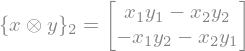

In [ ]:
# ---- MOVE 1: the three channels, and how they transform. -----------------
x = sp.symbols("x1 x2"); y = sp.symbols("y1 y2")
cg = S3.doublet_product
P = cg(x, y)
for ch in ("1", "1p", "2"):
    display(sp.Eq(sp.Symbol(r"\{x \otimes y\}_{%s}" % ch),
                  sp.Matrix(P[ch]) if ch == "2" else P[ch], evaluate=False))


In [ ]:
# ---- MOVE 2 + 4: each channel must transform as its label claims. --------
def act(vec, M):
    # The doublet (v1, v2) under a generator matrix M.
    return tuple(sum(M[i, k] * vec[k] for k in range(2)) for i in range(2))


for gi, M in enumerate(S3_GENS["2"]):
    xp, yp = act(x, M), act(y, M)
    Pp = cg(xp, yp)
    # the singlet is untouched
    assert sp.simplify(sp.expand(Pp["1"] - P["1"])) == 0
    # the 1' picks up det(M) = +1 for the rotation, -1 for the reflection
    sign = sp.simplify(M.det())
    assert sp.simplify(sp.expand(Pp["1p"] - sign * P["1p"])) == 0
    # the doublet channel transforms as a doublet
    want = act(P["2"], M)
    assert all(sp.simplify(sp.expand(Pp["2"][i] - want[i])) == 0 for i in range(2))
ok("the three channels transform as 1, 1' (with sign = det) and 2 -- verified, "
   "not quoted")


✓ the three channels transform as 1, 1' (with sign = det) and 2 -- verified, not quoted


### 5.1 The $\mathbf 1'$ trap

Now the thing that catches people.


In [ ]:
# ---- the antisymmetric singlet vanishes on a repeated doublet ------------
same = cg(x, x)
print("  {x (x) x}_1  =", sp.expand(same["1"]))
print("  {x (x) x}_1' =", sp.expand(same["1p"]), "   <-- identically zero")
assert sp.expand(same["1p"]) == 0
ok("1' is ANTISYMMETRIC, so it vanishes when both legs are the same doublet")


  {x (x) x}_1  = x1**2 + x2**2
  {x (x) x}_1' = 0    <-- identically zero
✓ 1' is ANTISYMMETRIC, so it vanishes when both legs are the same doublet


$x_1x_2-x_2x_1=0$. Obvious once written — and invisible if you copy a Clebsch–Gordan table
into a model with one doublet and start counting terms. It is the same fact §4.1 measured
from the other side: with one doublet, channels that need two *distinct* multiplets simply
are not available.

**Model-building consequence.** The number of terms in your potential depends on how many
distinct multiplets you have, not just on the group. Two $S_3$ doublets $(H_1,H_2)$ and
$(H_3,H_4)$ give you $\mathbf 1'$ couplings that a single doublet cannot form.

Now construct the quartics and confirm both counts from §4.


In [ ]:
# ---- MOVE 3: construct, and check the rank against the prediction. -------
z = sp.symbols("z1 z2"); w = sp.symbols("w1 w2")
D = {"x": x, "y": y, "z": z, "w": w}
allv = [*x, *y, *z, *w]

def rank_of(exprs, gens):
    monos = sorted({m for e in exprs for m in sp.Poly(e, *gens).monoms()})
    return sp.Matrix([[sp.Poly(e, *gens).coeff_monomial(m) for m in monos]
                      for e in exprs]).rank()

cands, labels = [], []
for (p, q), (r_, u) in itertools.combinations(
        list(itertools.combinations("xyzw", 2)), 2):
    if set(p + q) | set(r_ + u) != set("xyzw"):
        continue
    for ch in ("1", "1p"):                       # pair each channel with itself
        cands.append(sp.expand(cg(D[p], D[q])[ch] * cg(D[r_], D[u])[ch]))
        labels.append("(%s%s)_%s (%s%s)_%s" % (p, q, ch, r_, u, ch))
    d1, d2 = cg(D[p], D[q])["2"], cg(D[r_], D[u])["2"]
    cands.append(sp.expand(cg(d1, d2)["1"]))     # doublet x doublet -> singlet
    labels.append("(%s%s)_2 . (%s%s)_2" % (p, q, r_, u))

print("built %d candidate quartics from four distinct doublets:" % len(cands))
for l in labels:
    print("   ", l)
r4 = rank_of(cands, allv)
print("\n  independent among them:", r4, "  (characters predicted %s)" % quartic_four)
assert r4 == quartic_four == 3
ok("9 candidates, rank 3 -- six relations, and the count matches the character "
   "prediction exactly")


built 9 candidate quartics from four distinct doublets:
    (xy)_1 (zw)_1
    (xy)_1p (zw)_1p
    (xy)_2 . (zw)_2
    (xz)_1 (yw)_1
    (xz)_1p (yw)_1p
    (xz)_2 . (yw)_2
    (xw)_1 (yz)_1
    (xw)_1p (yz)_1p
    (xw)_2 . (yz)_2

  independent among them: 3   (characters predicted 3)
✓ 9 candidates, rank 3 -- six relations, and the count matches the character prediction exactly


In [ ]:
# ---- and the one-doublet case, against the Molien prediction -------------
one = [sp.expand(cg(x, x)["1"]**2),
       sp.expand(cg(cg(x, x)["2"], cg(x, x)["2"])["1"])]
print("  (x.x)^2          =", one[0])
print("  {xx}_2 . {xx}_2  =", one[1])
r1 = rank_of(one, list(x))
print("\n  independent:", r1, "  (Molien predicted %s)" % quartic_one)
assert r1 == quartic_one == 1
ok("two ways to write it, one invariant -- the doublet channel gives nothing new")


  (x.x)^2          = x1**4 + 2*x1**2*x2**2 + x2**4
  {xx}_2 . {xx}_2  = x1**4 + 2*x1**2*x2**2 + x2**4

  independent: 1   (Molien predicted 1)
✓ two ways to write it, one invariant -- the doublet channel gives nothing new


Both predictions land. This is the loop worth internalising:

**count with characters → construct with Clebsch–Gordan → check the rank.**

If the rank comes out *below* the character count you have made an algebra slip; if it
comes out *above*, your "invariants" are not all invariant. Either way the disagreement
is informative, which is what makes the check worth doing.


---
## 6. The Reynolds projector: invariants without tables

Clebsch–Gordan coefficients are elegant but they must be *derived per group* and they
depend on the basis. There is a blunter tool that always works, needs no tables, and is
what `feynlag` actually uses — **group averaging**:

$$P(m)\;=\;\frac{1}{|G|}\sum_{g\in G} g\cdot m .$$

$P$ is a projector onto the invariant subspace: averaging something already invariant
returns it unchanged, and averaging anything else either produces its invariant part or
kills it outright.

> **Before running the next cell.** Apply $P$ to a monomial with a definite
> $\mathbb{Z}_N$ charge. The average is $\frac1N\sum_k \omega^{kq}m$ — a geometric series.
> For which charges $q$ is it $m$, and for which is it $0$? Convince yourself this
> reproduces the familiar selection rule *without anyone having stated the rule*.


In [ ]:
# ---- Z_N: the Reynolds average IS the charge selection rule -------------
Z3 = ZN("Z3", 3)
A, B = Scalar("A", real=True), Scalar("B", real=True)
Z3.assign(1, A)          # charge 1
Z3.assign(2, B)          # charge 2
sA, sB = A.components[0], B.components[0]

for expr, why in ((sA**3, "charge 3 = 0 mod 3"), (sA * sB, "charge 1+2 = 0 mod 3"),
                  (sA**2, "charge 2 != 0 mod 3"), (sA * sB**2, "charge 5 = 2 != 0")):
    # expand_complex: sympy leaves the omega average as
    # (1 - (-1)^(1/3) + (-1)^(2/3))/3, which IS zero but does not display so
    P_ = sp.simplify(sp.expand_complex(reynolds_project(expr, [Z3])))
    print("  P(%-8s) = %-8s   %s" % (expr, P_, why))
ok("the Reynolds average reproduces 'total charge = 0 mod N' with no rule "
   "written down")


  P(A**3    ) = A**3       charge 3 = 0 mod 3
  P(A*B     ) = A*B        charge 1+2 = 0 mod 3
  P(A**2    ) = 0          charge 2 != 0 mod 3
  P(A*B**2  ) = 0          charge 5 = 2 != 0
✓ the Reynolds average reproduces 'total charge = 0 mod N' with no rule written down


In [ ]:
# ---- S3: averaging produces genuine invariant COMBINATIONS --------------
X1, X2 = Scalar("X1", real=True), Scalar("X2", real=True)
s3b = S3(); s3b.assign("2", X1, X2)
r1_, r2_ = X1.components[0], X2.components[0]

for expr in (r1_**2, r1_ * r2_, r1_**3, r1_**2 * r2_):
    print("  P(%-8s) =" % expr, sp.simplify(sp.expand(reynolds_project(expr, [s3b]))))


  P(X1**2   ) = X1**2/2 + X2**2/2
  P(X1*X2   ) = 0


  P(X1**3   ) = X1*(X1**2 - 3*X2**2)/4


  P(X1**2*X2) = 0


Note the difference in character between the two groups. For $\mathbb{Z}_N$ every monomial
is an eigenvector of the projector — it survives whole or dies. For $S_3$ the projector
*mixes* monomials: $P(r_1^2)=\tfrac12(r_1^2+r_2^2)$ is a combination that **no single
monomial realises**. That is exactly why an abelian symmetry can be enforced by
bookkeeping charges, while a non-abelian one cannot.

Check it against §5's Clebsch–Gordan answer: the projections must lie in the span the CG
construction produced.


In [ ]:
# ---- MOVE 4: Reynolds and Clebsch-Gordan must agree ---------------------
I2_cg = cg((r1_, r2_), (r1_, r2_))["1"]                  # r1^2 + r2^2
I3_cg = sp.expand(cg((r1_, r2_), cg((r1_, r2_), (r1_, r2_))["2"])["1"])

P2 = sp.expand(reynolds_project(r1_**2, [s3b]))
P3 = sp.expand(reynolds_project(r1_**3, [s3b]))
for P_, I_, name in ((P2, I2_cg, "quadratic"), (P3, I3_cg, "cubic")):
    ratio = sp.simplify(sp.cancel(P_ / I_))
    print("  %-9s : P = (%s) x the CG invariant" % (name, ratio))
    assert ratio.is_number and ratio != 0
ok("the Reynolds projections are proportional to the CG invariants -- two "
   "independent routes to the same subspace")

# and the projector really is a projector: P(P(m)) = P(m)
assert sp.simplify(sp.expand(reynolds_project(P2, [s3b]) - P2)) == 0
ok("P^2 = P")


  quadratic : P = (1/2) x the CG invariant
  cubic     : P = (1/4) x the CG invariant
✓ the Reynolds projections are proportional to the CG invariants -- two independent routes to the same subspace
✓ P^2 = P


---
## 7. Basis dependence — and why we counted with characters

The $S_3$ doublet has (at least) two bases in common use: the **real orthogonal** one this
library commits to, and a **complex** one in which the $2\pi/3$ rotation is diagonal,
$\rho(a)=\mathrm{diag}(\omega,\omega^2)$ with $\omega=e^{2\pi i/3}$. Papers use both, often
without saying which — and every Clebsch–Gordan coefficient differs between them.

> **Before running the next cell.** A change of basis is $\rho\to U\rho U^{-1}$. Which of
> the following survive it: the individual matrix entries, the trace, the determinant, the
> eigenvalues, the number of invariants? Decide before looking, then note which of those
> the counting in §4 relied on.


complex basis:


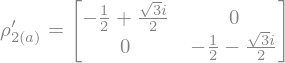

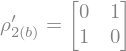


  chi_2 (real basis)    : [2, -1, 0, -1, 0, 0]
  chi_2 (complex basis) : [2, -1, 0, -1, 0, 0]
✓ the matrices changed completely; the character did not


In [ ]:
# ---- the same rep, a different basis ------------------------------------
U = sp.Matrix([[1, sp.I], [1, -sp.I]]) / sp.sqrt(2)
a2c = sp.simplify(U * a2 * U.inv())
b2c = sp.simplify(U * b2 * U.inv())
print("complex basis:")
display(sp.Eq(sp.Symbol(r"\rho'_2(a)"), a2c, evaluate=False))
display(sp.Eq(sp.Symbol(r"\rho'_2(b)"), b2c, evaluate=False))

COMPLEX = {"1": S3_GENS["1"], "1p": S3_GENS["1p"], "2": [a2c, b2c]}
chi_c = {lab: [sp.nsimplify(sp.expand(sp.trace(rho(lab, w, COMPLEX))))
               for w in WORDS] for lab in COMPLEX}
print("\n  chi_2 (real basis)    :", chi["2"])
print("  chi_2 (complex basis) :", chi_c["2"])
assert all(sp.simplify(chi["2"][i] - chi_c["2"][i]) == 0 for i in range(G))
ok("the matrices changed completely; the character did not")


In [ ]:
# ---- so every count from section 4 is unchanged -------------------------
def n_inv_basis(chars, n):
    return sp.simplify(sum(chars[i]**n for i in range(G)) / G)

for n in (2, 3, 4):
    a_, b_ = n_inv_basis(chi["2"], n), n_inv_basis(chi_c["2"], n)
    print("  2^(x%d):  real basis %s   complex basis %s" % (n, a_, b_))
    assert a_ == b_
ok("identical invariant counts in both bases -- the PHYSICS cannot depend on "
   "the basis, and characters are the basis-independent way to see it")


  2^(x2):  real basis 1   complex basis 1
  2^(x3):  real basis 1   complex basis 1
  2^(x4):  real basis 3   complex basis 3
✓ identical invariant counts in both bases -- the PHYSICS cannot depend on the basis, and characters are the basis-independent way to see it


**The judgment:** counts are basis-independent, *coefficients are not*. When you take a
Clebsch–Gordan table from a paper you are importing its basis convention along with it,
and mixing two papers' tables silently gives wrong relative factors. The count is the safe
thing to compare across sources; the coefficients are not.

`feynlag` states its convention explicitly in `S3.doublet_product`'s docstring — the real
orthogonal basis, with the $\mathbf 2$ channel derived from
$D=\overline{w\,v}$, $w=x_1+ix_2$.


---
## 8. Complex fields and the conjugate leg

Real scalars are the easy case. A realistic model has **complex** fields, and then a term
like $\bar\psi\,\psi$ has one leg transforming with $M$ and the other with something else.
Getting that "something else" wrong is a silent error — the term looks invariant and is
not.

Requiring $\sum_i \bar\psi'_i\psi'_i = \sum_i\bar\psi_i\psi_i$ under
$\psi_i\to\sum_k M[i,k]\psi_k$ and $\bar\psi_i\to\sum_k X[i,k]\bar\psi_k$ forces
$X^{\mathsf T}M=\mathbb 1$, i.e.

$$X = (M^{-1})^{\mathsf T}.$$

> **Before running the next cell.** For which kind of $M$ does $X$ coincide with $M$
> itself? Check your answer against the two groups in play: $S_3$'s irreps are real
> orthogonal, $\mathbb{Z}_N$'s are complex phases. Predict which one has $X\neq M$ — and
> what would break if you used $M$ on both legs there.


In [ ]:
# ---- X = (M^-1)^T, computed for both groups ------------------------------
print("S_3 doublet:")
for gi, M in enumerate(S3_GENS["2"]):
    X = sp.simplify(M.inv().T)
    print("   generator %d :  X == M ?" % gi, sp.simplify(X - M) == sp.zeros(2, 2),
          "  (M orthogonal?", sp.simplify(M.T * M) == sp.eye(2), ")")
    assert sp.simplify(X - M) == sp.zeros(2, 2)
ok("for S_3, X = M exactly -- because the irreps are REAL ORTHOGONAL")

print("\nZ_3 charge-1 irrep:")
M = sp.Matrix([[sp.exp(2 * sp.pi * sp.I / 3)]])
X = sp.simplify(M.inv().T)
print("   M =", M[0], "   X =", X[0], "   X == conj(M)?",
      sp.simplify(X[0] - sp.conjugate(M[0])) == 0)
assert sp.simplify(X[0] - M[0]) != 0
ok("for Z_3, X = conj(M) != M -- using M on both legs would give charge 2, "
   "not 0, and the 'invariant' would not be one")


S_3 doublet:
   generator 0 :  X == M ? True   (M orthogonal? True )
   generator 1 :  X == M ? True   (M orthogonal? True )
✓ for S_3, X = M exactly -- because the irreps are REAL ORTHOGONAL

Z_3 charge-1 irrep:
   M = exp(2*I*pi/3)    X = exp(-2*I*pi/3)    X == conj(M)? True
✓ for Z_3, X = conj(M) != M -- using M on both legs would give charge 2, not 0, and the 'invariant' would not be one


This is not a hypothetical: it is exactly what `DiscreteSymmetry.fermion_generator_data`
computes, via `M.inv().T` rather than by assuming. The library derives it because the two
cases genuinely differ, and the $S_3$ coincidence would otherwise hide the bug until
someone used $\mathbb{Z}_N$.

Let the invariance checker demonstrate the failure directly.


In [ ]:
# ---- a wrong assignment must FAIL the check -----------------------------
C_, D_ = Scalar("C", real=True), Scalar("D", real=True)
z3b = ZN("Z3b", 3); z3b.assign(1, C_); z3b.assign(1, D_)   # both charge +1
sC, sD = C_.components[0], D_.components[0]

good, bad = sC * sD**2, sC * sD          # charges 3 = 0 mod 3, and 2 != 0
for expr in (good, bad):
    inv, residual = check_discrete_invariance(expr, z3b)
    print("  %-8s invariant? %-6s" % (expr, inv),
          "" if inv else "residual: %s"
          % sp.simplify(sp.expand_complex(residual[0][1])))
assert check_discrete_invariance(good, z3b)[0]
assert not check_discrete_invariance(bad, z3b)[0]
ok("the checker accepts total charge 0 mod 3 and rejects the rest, with the "
   "offending residual shown")


  C*D**2   invariant? True   
  C*D      invariant? False  residual: C*D*(-3 - sqrt(3)*I)/2
✓ the checker accepts total charge 0 mod 3 and rejects the rest, with the offending residual shown


---
## 9. Into a model: the $S_3$ three-Higgs-doublet potential

Everything so far was group theory. Now the model-building question: assign three Higgs
doublets to $S_3$ as $\mathbf 2\oplus\mathbf 1$ — the doublet $(H_1,H_2)$ and the singlet
$H_S$ — and ask **how many terms the potential has**.

The fields are complex $SU(2)$ doublets, so the potential is built from gauge-invariant
bilinears $H_a^\dagger H_b$, and both conjugate and non-conjugate legs appear. For $S_3$
that costs us nothing: §8 showed $X=M$ and §3 showed the characters are real, so
$\bar\chi=\chi$ and the counting is unchanged. (For $\mathbb{Z}_N$ it would not be.)

> **Before running the next cell.** The library's enumerator will report a number. Before
> you see it, ask what it *should* be: how many quadratic terms can you form
> ($H^\dagger H$ is degree 2 in fields), and roughly how many quartic? Then, more usefully,
> ask what the symmetry has **forbidden** — a general 3HDM potential has far more
> parameters than this.


In [ ]:
# ---- MOVE 1: enumerate the S3-invariant potential ------------------------
terms = suggest_potential([H1, H2, HS], [SU2L, U1Y], discrete_groups=[s3])
print("suggest_potential found %d independent operators" % len(terms))

fieldsyms = [c for f in (H1, H2, HS) for c in list(f.components)]
allsyms = fieldsyms + [sp.conjugate(c) for c in fieldsyms]
deg = lambda e: sp.Poly(sp.expand(e), *allsyms).total_degree()
quad = [t for t in terms if deg(t.expr) == 2]
quart = [t for t in terms if deg(t.expr) == 4]
print("   quadratic (mass) terms :", len(quad))
print("   quartic  (coupling)    :", len(quart))
assert (len(terms), len(quad), len(quart)) == (10, 2, 8)
ok("2 mass + 8 quartic = 10 operators -- the S3 3HDM basis")


suggest_potential found 10 independent operators
   quadratic (mass) terms : 2
   quartic  (coupling)    : 8
✓ 2 mass + 8 quartic = 10 operators -- the S3 3HDM basis


Two mass terms and eight quartics. Compare that with an **unconstrained** three-Higgs-doublet
potential, where every $H_a^\dagger H_b$ pairing is allowed independently — that is where
the symmetry earns its keep.


In [ ]:
# ---- MOVE 2 + 3: what did the symmetry forbid? --------------------------
free = suggest_potential([H1, H2, HS], [SU2L, U1Y])          # no discrete group
print("without S3 : %d operators" % len(free))
print("with    S3 : %d operators" % len(terms))
print("forbidden  : %d" % (len(free) - len(terms)))
ok("imposing S3 removes %d of the %d parameters -- that is the entire point of "
   "a flavour symmetry" % (len(free) - len(terms), len(free)))


without S3 : 33 operators
with    S3 : 10 operators
forbidden  : 23
✓ imposing S3 removes 23 of the 33 parameters -- that is the entire point of a flavour symmetry


In [ ]:
# ---- MOVE 4: every surviving term really is invariant --------------------
for t in terms:
    inv, residual = check_discrete_invariance(sp.expand(t.expr), s3)
    assert inv, (t.expr, residual)
ok("all %d enumerated operators pass check_discrete_invariance independently "
   "of how they were produced" % len(terms))

# and a deliberately S3-breaking term must be rejected
bad_term = sp.expand((dag(H1) * H1.mat)[0]**2)      # H1 alone, not the doublet
assert not check_discrete_invariance(bad_term, s3)[0]
ok("(H1+ H1)^2 alone is correctly REJECTED -- the doublet must appear "
   "symmetrically, so the check has teeth")


✓ all 10 enumerated operators pass check_discrete_invariance independently of how they were produced


✓ (H1+ H1)^2 alone is correctly REJECTED -- the doublet must appear symmetrically, so the check has teeth


The 10-operator basis is what `THDM_S3_Tutorial` and the 3HDM-$S_3$ research notebooks
build on: 2 mass parameters $\mu^2$ and 8 quartics $\lambda_{1..8}$. You now know where the
number 8 comes from, and — more importantly — that you could have predicted it.


---
## 10. Capstone: $A_4$ from scratch

$S_3$ is the warm-up. The workhorse of flavour model building is $A_4$ — the even
permutations of four objects, the rotation group of the tetrahedron, order 12 — because it
has a **3-dimensional irrep** that can hold three generations at once.

`feynlag` ships only $\mathbb{Z}_N$ and $S_3$. But `DiscreteSymmetry` advertises itself as
extensible, and the contract is small: supply `_irrep_generators`, one matrix per
generator per irrep. Let us hold it to that.

$A_4$ is presented by $S^2=T^3=(ST)^3=e$, with irreps $\mathbf 1,\mathbf 1',\mathbf 1'',
\mathbf 3$ (note $1+1+1+9=12$ ✓). In the standard basis

$$S=\mathrm{diag}(1,-1,-1),\qquad T=\begin{pmatrix}0&1&0\\0&0&1\\1&0&0\end{pmatrix},$$

and the three singlets are distinguished by $T\to 1,\omega,\omega^2$.

> **Before running the next cells.** $A_4$ has four irreps, so four conjugacy classes.
> Predict $\chi_3$: $\chi_3(e)=3$ certainly. $S$ is a double transposition — what is
> $\mathrm{Tr}\,S$? $T$ is a 3-cycle, and a cyclic permutation matrix has trace equal to
> the number of fixed points — how many does it have? Fill in the row before you look.


In [ ]:
# ---- MOVE 1: define A4 on top of the shipped base class -----------------
w = sp.exp(2 * sp.pi * sp.I / 3)
S_ = sp.Matrix([[1, 0, 0], [0, -1, 0], [0, 0, -1]])
T_ = sp.Matrix([[0, 1, 0], [0, 0, 1], [1, 0, 0]])


class A4(DiscreteSymmetry):
    # The alternating group A_4: irreps 1, 1', 1'' and 3.

    def __init__(self, name="A4"):
        super().__init__(name)
        self._irrep_generators = {
            "1":   [sp.Matrix([[1]]), sp.Matrix([[1]])],
            "1p":  [sp.Matrix([[1]]), sp.Matrix([[w]])],
            "1pp": [sp.Matrix([[1]]), sp.Matrix([[w**2]])],
            "3":   [S_, T_],
        }


A4_GENS = A4()._irrep_generators
for name, M, n in (("S^2", S_**2, 2), ("T^3", T_**3, 3), ("(ST)^3", (S_ * T_)**3, 3)):
    assert sp.simplify(M) == sp.eye(3), name
    print("  %-7s = identity  ✓" % name)
ok("S^2 = T^3 = (ST)^3 = e -- the presentation of A_4")


  S^2     = identity  ✓
  T^3     = identity  ✓
  (ST)^3  = identity  ✓
✓ S^2 = T^3 = (ST)^3 = e -- the presentation of A_4


In [ ]:
# ---- MOVE 2: close it, and derive the character table -------------------
W4 = close_group(A4_GENS["3"])
G4 = len(W4)
print("|A_4| =", G4)
assert G4 == 12
assert sum(A4_GENS[l][0].shape[0]**2 for l in A4_GENS) == G4
ok("order 12, and sum (dim r)^2 = 1+1+1+9 = 12 -- the irrep list is complete")

chi4 = {lab: [sp.nsimplify(sp.expand(sp.trace(rho(lab, wd, A4_GENS))))
              for wd in W4] for lab in A4_GENS}

classes4 = conjugacy_classes(W4, A4_GENS, "3")
print("\nconjugacy classes:", [len(cl) for cl in classes4], " (sizes)")
names4 = ["e", "S  (double transp.)", "T  (3-cycle)", "T^2 (3-cycle)"]
hdr4 = "%-6s" % "" + "".join("%-24s" % n for n in names4)
print(); print(hdr4); print("-" * len(hdr4))
for lab in ("1", "1p", "1pp", "3"):
    row = "%-6s" % lab
    for cl in classes4:
        row += "%-24s" % sp.simplify(sp.expand_complex(chi4[lab][W4.index(cl[0])]))
    print(row)

for lab in A4_GENS:                       # constant on classes, as before
    for cl in classes4:
        vals = {sp.simplify(chi4[lab][W4.index(w)] - chi4[lab][W4.index(cl[0])])
                for w in cl}
        assert vals == {0}, (lab, cl)
ok("A_4's characters are constant on its 4 conjugacy classes")


|A_4| = 12
✓ order 12, and sum (dim r)^2 = 1+1+1+9 = 12 -- the irrep list is complete

conjugacy classes: [1, 3, 4, 4]  (sizes)

      e                       S  (double transp.)     T  (3-cycle)            T^2 (3-cycle)           
------------------------------------------------------------------------------------------------------
1     1                       1                       1                       1                       
1p    1                       1                       -1/2 + sqrt(3)*I/2      -1/2 - sqrt(3)*I/2      
1pp   1                       1                       -1/2 - sqrt(3)*I/2      -1/2 + sqrt(3)*I/2      
3     3                       -1                      0                       0                       
✓ A_4's characters are constant on its 4 conjugacy classes


In [ ]:
# ---- MOVE 4: orthonormality, on a group the library never saw -----------
inner4 = lambda p, q: sp.simplify(
    sum(sp.conjugate(chi4[p][i]) * chi4[q][i] for i in range(G4)) / G4)
for p in A4_GENS:
    for q in A4_GENS:
        assert inner4(p, q) == (1 if p == q else 0), (p, q, inner4(p, q))
ok("<chi_r, chi_s> = delta_rs for all 16 pairs -- A_4's character table is "
   "consistent, and nothing about it was typed in")

print()
for n in (2, 3, 4):
    print("  invariants in 3^(x%d) (distinct triplets) : %s"
          % (n, sp.simplify(sum(chi4["3"][i]**n for i in range(G4)) / G4)))


✓ <chi_r, chi_s> = delta_rs for all 16 pairs -- A_4's character table is consistent, and nothing about it was typed in

  invariants in 3^(x2) (distinct triplets) : 1
  invariants in 3^(x3) (distinct triplets) : 2
  invariants in 3^(x4) (distinct triplets) : 7


$\chi_3=(3,-1,0,0)$: the double transposition $S$ has trace $-1$, and the 3-cycles are
traceless because a 3-cycle permutation matrix has no fixed points.

The counts are the reason $A_4$ is the flavour group of choice: **one** invariant in
$\mathbf 3\otimes\mathbf 3$ (so a mass term exists), and **two** in
$\mathbf 3\otimes\mathbf 3\otimes\mathbf 3$ — the symmetric and antisymmetric cubics, which
is exactly the freedom a Yukawa sector needs to generate non-trivial mixing.

Finally: do the *shipped tools* work on this group they have never met?


In [ ]:
# ---- the library's machinery, unchanged, on A4 --------------------------
a4 = A4()
F1, F2, F3 = (Scalar(n, real=True) for n in ("F1", "F2", "F3"))
a4.assign("3", F1, F2, F3)
f1, f2, f3 = (f.components[0] for f in (F1, F2, F3))

inv, _ = check_discrete_invariance(f1**2 + f2**2 + f3**2, a4)
notinv, residual = check_discrete_invariance(f1**2, a4)
print("  check_discrete_invariance(F1^2 + F2^2 + F3^2) :", inv)
print("  check_discrete_invariance(F1^2)               :", notinv,
      "   residual:", sp.simplify(residual[0][1]))
assert inv and not notinv

print("\n  reynolds_project(F1^2)  =", sp.simplify(reynolds_project(f1**2, [a4])))
print("  reynolds_project(F1 F2) =", sp.simplify(reynolds_project(f1 * f2, [a4])))
assert sp.simplify(reynolds_project(f1 * f2, [a4])) == 0
ok("check_discrete_invariance and reynolds_project both work on A_4 with no "
   "library change -- the projector finds (F1^2+F2^2+F3^2)/3 and kills F1 F2")


  check_discrete_invariance(F1^2 + F2^2 + F3^2) : True
  check_discrete_invariance(F1^2)               : False    residual: -F1**2 + F2**2



  reynolds_project(F1^2)  = F1**2/3 + F2**2/3 + F3**2/3
  reynolds_project(F1 F2) = 0
✓ check_discrete_invariance and reynolds_project both work on A_4 with no library change -- the projector finds (F1^2+F2^2+F3^2)/3 and kills F1 F2


In [ ]:
# ---- and the count agrees with explicit construction --------------------
quad_inv = sp.expand(reynolds_project(f1**2, [a4]))
n_quad = sp.simplify(sum(chi4["3"][i]**2 for i in range(G4)) / G4)
basis = [sp.expand(reynolds_project(m, [a4]))
         for m in (f1**2, f2**2, f3**2, f1*f2, f1*f3, f2*f3)]
nz = [b for b in basis if b != 0]
r = sp.Matrix([[sp.Poly(b, f1, f2, f3).coeff_monomial(m)
                for m in sorted({m for e in nz
                                 for m in sp.Poly(e, f1, f2, f3).monoms()})]
               for b in nz]).rank()
print("  projecting all 6 quadratic monomials: %d survive, rank %d" % (len(nz), r))
print("  characters predicted:", n_quad)
assert r == n_quad == 1
ok("one quadratic invariant, predicted and constructed -- the same loop as "
   "section 5, on a brand-new group")


  projecting all 6 quadratic monomials: 3 survive, rank 1
  characters predicted: 1
✓ one quadratic invariant, predicted and constructed -- the same loop as section 5, on a brand-new group


---
## 11. Recap

**The mechanics.**

1. A finite group is its generators; closing them under multiplication regenerates it.
   Checking invariance under generators *is* checking it under the group.
2. A representation is any $\rho$ with $\rho(g)\rho(h)=\rho(gh)$ — injectivity not required.
   The trivial rep is "invariant"; the sign rep $\mathbf 1'$ is not.
3. Characters are traces. Basis-independent, constant on classes, orthonormal:
   $\sum_r(\dim r)^2=|G|$ and #irreps = #classes tell you when your list is complete.

**The tools, in the order you should reach for them.**

| question | tool |
|---|---|
| how many invariants, $n$ *distinct* multiplets? | $\frac1{|G|}\sum_g\prod_i\chi_i(g)$ |
| how many, from **one** multiplet? | the Molien series |
| what are they, explicitly? | Clebsch–Gordan (`S3.doublet_product`) |
| …without a CG table? | the Reynolds projector (`reynolds_project`) |
| is this term invariant? | `check_discrete_invariance` |
| what is the whole basis? | `suggest_potential(..., discrete_groups=[...])` |

**The four traps**, each of which produced a wrong answer above before the check caught it:

- **$\mathbf 1'$ vanishes on a repeated multiplet.** One $S_3$ doublet forms no
  antisymmetric singlet with itself.
- **Distinct legs versus one field.** Four distinct doublets give 3 quartic invariants;
  one doublet gives 1. Use characters for the first, Molien for the second.
- **Basis conventions.** CG coefficients differ between the real and complex $S_3$ bases;
  counts do not. Compare counts across papers, never coefficients.
- **The conjugate leg.** $X=(M^{-1})^{\mathsf T}$, which equals $M$ only for real
  orthogonal irreps. True for $S_3$, false for $\mathbb{Z}_N$ — so the $S_3$ coincidence
  hides the error.

**And the model-building punchline.** Imposing $S_3$ on three Higgs doublets cuts the
potential to 2 mass terms and 8 quartics; the forbidden operators are what the symmetry
buys you. You can compute that number from the character table before writing a single
term — and `A_4`, a group the library does not ship, needed no library change at all.

Where to go next: `THDM_S3_Tutorial` builds the 3HDM-$S_3$ potential from these
invariants and breaks the symmetry; `ModelBuilding_Tutorial` does the same enumeration
for continuous $U(1)$ charges with anomaly cancellation; `SUN_Groups_Tutorial` is the
continuous-group counterpart to this notebook.
